# Homework 4
## Ram Kakinada
## ECE 580C7

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = torch.device('cuda:0') # use the first GPU on this system


In [4]:
transform = transforms.Compose([
    transforms.ToTensor()])
dataset_train = datasets.MNIST(root='data',train=True,download=True,transform=transform)
dataset_val = datasets.MNIST(root='data',train=False,download=True, transform=transform)

## Fully Connected Network 500 epochs

In [3]:
## Altered input layer for 28x28 grayscale and messed around with the hidden layer sizes as well
model = nn.Sequential(
    nn.Linear(784, 392),
    nn.Tanh(),
    nn.Linear(392, 196),
    nn.Tanh(),
    nn.Linear(196, 98),
    nn.Tanh(),
    nn.Linear(98, 10))
loss_fn = nn.CrossEntropyLoss()
model = model.to(device)

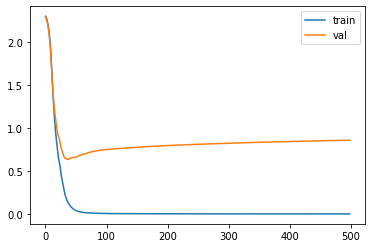

In [4]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.1,momentum=0.9)
loss_fn = nn.CrossEntropyLoss()

# load a limited set of the training data onto the GPU/
nTrain = 500
x = dataset_train.data.unsqueeze(1).float().to(device)/255.
y = dataset_train.targets.to(device)
x = x[0:nTrain] 
x=x.view(nTrain, -1) #Changes the dimensionality of the code to mesh with the rest of the code
y = y[0:nTrain]

# load entire validation set onto the GPU
x_val = dataset_val.data.unsqueeze(1).float().to(device)/255.
x_val = x_val.view(x_val.size(0),-1) #Switches the dimensions of the vector to work with the rest of the code
y_val = dataset_val.targets.to(device)

loss_train_vec = []
loss_val_vec = []

# training loop
n_epochs = 500
for epoch in range(1,n_epochs):
    yhat = model(x)

    loss = loss_fn(yhat,y)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    loss_train_vec += [loss.item()]
    
    # calculate validation loss
    with torch.no_grad():
        yhat_val = model(x_val)
        loss_val = loss_fn(yhat_val,y_val)
        
    loss_val_vec   += [loss_val.item()]
    
    # plot training/validation loss curves
    clear_output(wait=True)
    plt.plot(loss_train_vec)
    plt.plot(loss_val_vec)
    plt.legend(['train','val'])
    plt.show()

## Fully Connected Network 10000 epochs

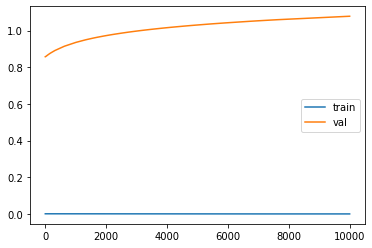

In [5]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.1,momentum=0.9)
loss_fn = nn.CrossEntropyLoss()

# load a limited set of the training data onto the GPU/
nTrain = 500
x = dataset_train.data.unsqueeze(1).float().to(device)/255.
y = dataset_train.targets.to(device)
x = x[0:nTrain] 
x=x.view(nTrain, -1) #Changes the dimensionality of the code to mesh with the rest of the code
y = y[0:nTrain]

# load entire validation set onto the GPU
x_val = dataset_val.data.unsqueeze(1).float().to(device)/255.
x_val = x_val.view(x_val.size(0),-1) #Switches the dimensions of the vector to work with the rest of the code
y_val = dataset_val.targets.to(device)

loss_train_vec = []
loss_val_vec = []

# training loop
n_epochs = 10000
for epoch in range(1,n_epochs):
    yhat = model(x)

    loss = loss_fn(yhat,y)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    loss_train_vec += [loss.item()]
    
    # calculate validation loss
    with torch.no_grad():
        yhat_val = model(x_val)
        loss_val = loss_fn(yhat_val,y_val)
        
    loss_val_vec   += [loss_val.item()]
    
    # plot training/validation loss curves
    clear_output(wait=True)
    plt.plot(loss_train_vec)
    plt.plot(loss_val_vec)
    plt.legend(['train','val'])
    plt.show()

## CNN For 500 Epochs

In [6]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1) # Switched to grayscale/single channel
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(392, 28) # Modified for 28x28 input
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(28, 10) # 28x28 and changed output nodes to 10
    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 392) # reshaped for 28x28 input
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out
model = Net() # Defining the model as net
model = model.to(device) # defining the device

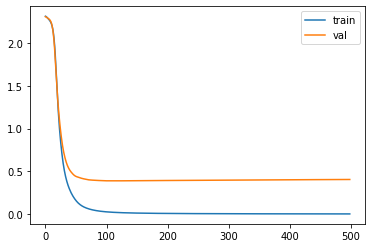

In [7]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.1,momentum=0.9)
loss_fn = nn.CrossEntropyLoss()

# load a limited set of the training data onto the GPU
nTrain = 500
x = dataset_train.data.unsqueeze(1).float().to(device)/255.
y = dataset_train.targets.to(device)
x = x[0:nTrain] 
y = y[0:nTrain]

# load entire validation set onto the GPU
x_val = dataset_val.data.unsqueeze(1).float().to(device)/255.
y_val = dataset_val.targets.to(device)

loss_train_vec = []
loss_val_vec = []

# training loop
n_epochs = 500
for epoch in range(1,n_epochs):
    yhat = model(x)

    loss = loss_fn(yhat,y)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    loss_train_vec += [loss.item()]
    
    # calculate validation loss
    with torch.no_grad():
        yhat_val = model(x_val)
        loss_val = loss_fn(yhat_val,y_val)
        
    loss_val_vec   += [loss_val.item()]
    
    # plot training/validation loss curves
    clear_output(wait=True)
    plt.plot(loss_train_vec)
    plt.plot(loss_val_vec)
    plt.legend(['train','val'])
    plt.show()

## CNN for 10000 epochs

In [9]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1) # Switched to grayscale
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(392, 28) # Modified for 28x28 input
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(28, 10) # 28x28 and changed output nodes to 10
    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 392) # reshaped for 28x28 input
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out
model = Net() # Defining the model as net
model = model.to(device) # defining the device

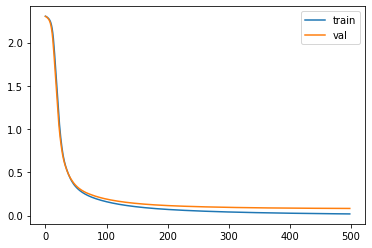

In [11]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.1,momentum=0.9)
loss_fn = nn.CrossEntropyLoss()

# load a limited set of the training data onto the GPU
nTrain = 10000
x = dataset_train.data.unsqueeze(1).float().to(device)/255.
y = dataset_train.targets.to(device)
x = x[0:nTrain] 
y = y[0:nTrain]

# load entire validation set onto the GPU
x_val = dataset_val.data.unsqueeze(1).float().to(device)/255.
y_val = dataset_val.targets.to(device)

loss_train_vec = []
loss_val_vec = []

# training loop
n_epochs = 500
for epoch in range(1,n_epochs):
    yhat = model(x)

    loss = loss_fn(yhat,y)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    loss_train_vec += [loss.item()]
    
    # calculate validation loss
    with torch.no_grad():
        yhat_val = model(x_val)
        loss_val = loss_fn(yhat_val,y_val)
        
    loss_val_vec   += [loss_val.item()]
    
    # plot training/validation loss curves
    clear_output(wait=True)
    plt.plot(loss_train_vec)
    plt.plot(loss_val_vec)
    plt.legend(['train','val'])
    plt.show()

## Discussion

#### Starting with the fully connected networs, there is definetely a case of overfitting going on with both the 500 epoch and 10000 epoch runs. From the code we can see for either trial, we can see that both times, the loss of the training set gets pretty close to zero at around 100 epochs. The Validations set, in both cases also seems to reach it lowest point around 50, however, as you go above a 100 epochs for either case, the loss of the training sets continue to get lower, but the validation set actually starts to uptick sharply. This indicated that we are running the training set for too long and that the code is defintelty overfitting and is therefore not very generlizable.

#### For the CNN's it becomes a little bit more complicated as if we take a look at the run for 500 epochs, the loss stablizies for both the training and validations sets, however, at the same time if we look at the output for 10000 epochs,, the trainiang and validation loss are both near zero and quite comparable. There is not a lot of overfitting going on as the loss does not spike up with more epochs, but instead continues to go down at a pretty stable rate. The generalization of the network actually gets better the longer you allow it to train on the training data. 